In [2]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
    
from abc import ABC, abstractmethod
from alpha_vantage.timeseries import TimeSeries
from scipy.stats import iqr
from scipy.optimize import minimize
from sklearn.model_selection import ParameterGrid
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from pykalman import KalmanFilter

In [320]:
spy_adj, meta_data = ts.get_daily_adjusted(symbol='TLT', outputsize='full')

ValueError: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints

In [3]:
api_key = 'your_alpha_vantage_api_key'
ts = TimeSeries(key=api_key, output_format='pandas')

In [4]:
spy, meta_data = ts.get_daily(symbol='TLT', outputsize='full')
spy

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2024-11-08,92.00,92.5955,91.8400,92.49,56756175.0
2024-11-07,90.75,91.6200,90.6500,91.33,56221411.0
2024-11-06,89.64,90.7200,89.5545,90.20,98895693.0
2024-11-05,92.03,92.9000,91.6000,92.74,46986037.0
2024-11-04,92.28,92.5700,91.6300,92.25,49747594.0
...,...,...,...,...,...
2002-08-01,82.54,83.0200,82.5400,83.00,25000.0
2002-07-31,81.95,82.8000,81.9000,82.53,29400.0
2002-07-30,81.75,81.9000,81.5200,81.52,6100.0


In [5]:
nasdaq, meta_data = ts.get_daily(symbol='IEI', outputsize='full')
nasdaq

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2024-11-08,116.46,116.610,116.280,116.35,1896172.0
2024-11-07,116.11,116.470,116.090,116.39,1950639.0
2024-11-06,115.69,116.010,115.670,115.81,2786048.0
2024-11-05,116.34,116.455,116.065,116.39,1314216.0
2024-11-04,116.56,116.650,116.310,116.46,1735760.0
...,...,...,...,...,...
2007-01-18,99.84,99.910,99.840,99.91,6200.0
2007-01-17,99.94,99.940,99.810,99.82,700.0
2007-01-16,99.83,99.830,99.830,99.83,600.0


In [6]:
prices = pd.merge(spy["4. close"], nasdaq["4. close"], left_index=True, right_index=True)
prices.columns = ["SPY", "QQQ"]
prices = prices.sort_index()
prices

,SPY,QQQ
date,,
2007-01-11,88.45,99.92
2007-01-12,88.04,99.93
2007-01-16,88.20,99.83
2007-01-17,87.96,99.82
2007-01-18,88.23,99.91
...,...,...
2024-11-04,92.25,116.46
2024-11-05,92.74,116.39
2024-11-06,90.20,115.81


In [7]:
start = "2010-08-01"
end = "2019-08-01"
tickers = ["TLT", "IEI"]
stock_1 = yf.download(tickers[0], start=start, end=end, interval="1d")
stock_2 = yf.download(tickers[1], start=start, end=end, interval="1d")
prices = pd.merge(stock_1["Close"], stock_2["Close"], left_index=True, right_index=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


/var/folders/4c/lbq7ysyx5zl93htfdcbr02br0000gn/T/ipykernel_50459/1941880473.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


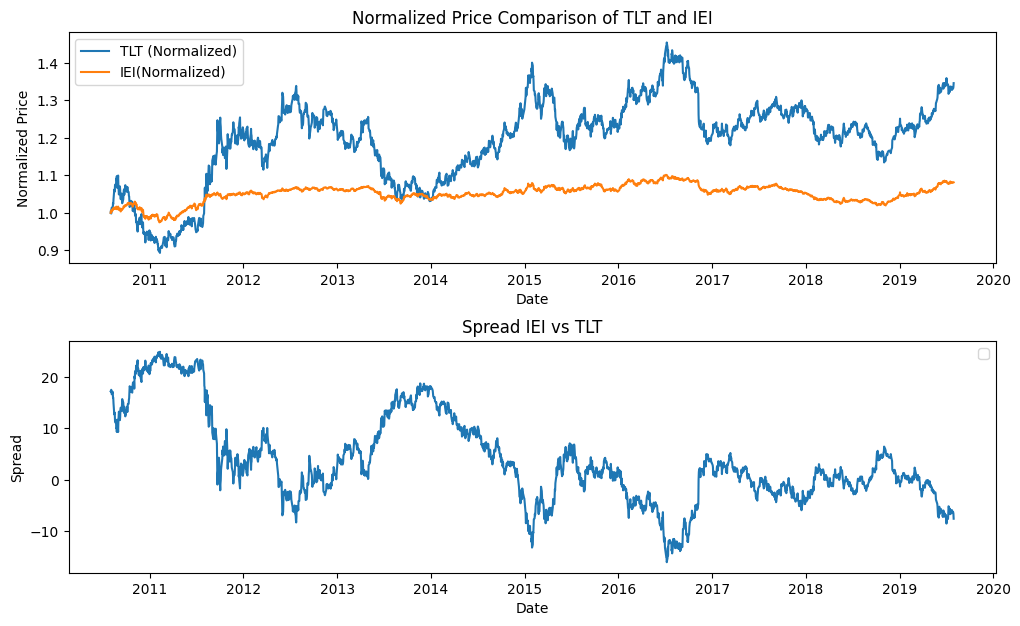

In [8]:
# Normalize both time series to their initial values
prices[tickers[0] + '_normalized'] = prices[tickers[0]] / prices[tickers[0]].iloc[0]
prices[tickers[1] + '_normalized'] = prices[tickers[1]] / prices[tickers[1]].iloc[0]
prices["spread"] = prices[tickers[1]] - prices[tickers[0]]

# Plot both normalized time series on the same plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plt.tight_layout(h_pad=3.5)
ax1.plot(prices.index, prices[tickers[0] + '_normalized'], label=tickers[0] + ' (Normalized)')
ax1.plot(prices.index, prices[tickers[1] + '_normalized'], label= tickers[1] + '(Normalized)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Price')
ax1.set_title(f'Normalized Price Comparison of {tickers[0]} and {tickers[1]}')
ax1.legend()

ax2.plot(prices.index, prices["spread"])
ax2.set_xlabel('Date')
ax2.set_ylabel('Spread')
ax2.set_title(f'Spread {tickers[1]} vs {tickers[0]}')
ax2.legend()
plt.show()

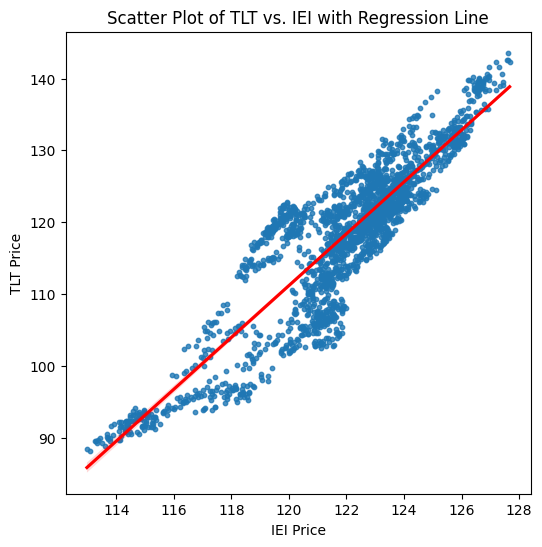

In [9]:
# Plot scatter plot with regression line
plt.figure(figsize=(6, 6))
sns.regplot(x=prices[tickers[1]], y=prices[tickers[0]], scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.xlabel(f'{tickers[1]} Price')
plt.ylabel(f'{tickers[0]} Price')
plt.title(f'Scatter Plot of {tickers[0]} vs. {tickers[1]} with Regression Line')
plt.show()

In [10]:
# Step 1: Run OLS regression with SPY as the dependent variable and Nasdaq as the independent variable
X = prices[tickers[0]]
Y = prices[tickers[1]]
X = sm.add_constant(X)  # Add a constant to the independent variable
model = sm.OLS(Y, X).fit()

# Extract the regression coefficient (beta)
beta = model.params[tickers[0]]
prices['coint_spread'] = prices[tickers[1]] - beta * prices[tickers[0]]
adf_test = adfuller(prices['coint_spread'])

print(f"Estimated Beta (Cointegration Coefficient): {beta}")
print(f"ADF p-value: {adf_test[1]}")

if adf_test[1] < 0.05:
    print("The cointegrated spread is stationary (cointegrated pair).")
else:
    print("The cointegrated spread is not stationary (not a cointegrated pair).")

# ADF test on the dollar neutral spread
adf_test = adfuller(prices['spread'])
print(f"ADF p-value: {adf_test[1]}")

if  adf_test[1]< 0.05:
    print("The dollard neutral spread is stationary (cointegrated pair).")
else:
    print("The dollard neutral spread is not stationary (not a cointegrated pair).")

Estimated Beta (Cointegration Coefficient): 0.21695102784880327
ADF p-value: 0.03369831388806505
The cointegrated spread is stationary (cointegrated pair).
ADF p-value: 0.30635838456559805
The dollard neutral spread is not stationary (not a cointegrated pair).


/var/folders/4c/lbq7ysyx5zl93htfdcbr02br0000gn/T/ipykernel_50459/2749648654.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


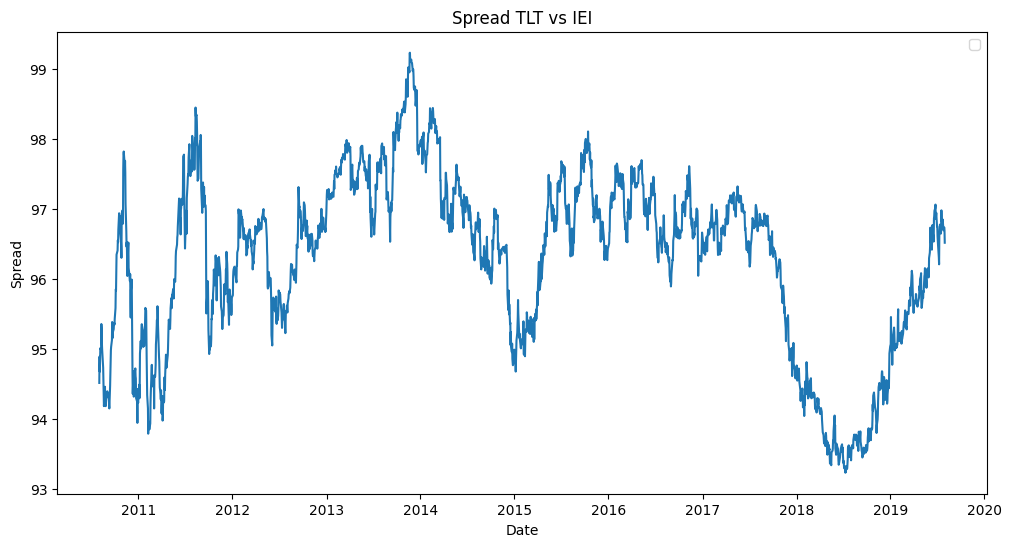

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices["coint_spread"])
plt.xlabel('Date')
plt.ylabel('Spread')
plt.title(f'Spread {tickers[0]} vs {tickers[1]}')
plt.legend()
plt.show()

In [ ]:
class Strategy(ABC):
    @abstractmethod
    def get_params(self):
        """Return strategy parameters."""
        pass

    @abstractmethod
    def set_params(self, **params):
        """Set strategy parameters."""
        pass

    @abstractmethod
    def generate_signals(self, spread):
        """Generate entry and exit signals based on the spread."""
        pass


def estimate_ou_parameters_ols(spread_window):
    X = spread_window[:-1].values         # X_t
    Y = spread_window[1:].values          # X_{t+1}
    X = sm.add_constant(X)                # Adds a constant term to the predictor

    model = sm.OLS(Y, X)
    results = model.fit()

    a = results.params[1]
    b = results.params[0]
    residuals = results.resid
    sigma = np.std(residuals)

    if a > 0 and a != 1:
        theta = -np.log(a)
        mu = b / (1 - a)
    else:
        raise ValueError("Invalid fitted parameters")

    return theta, mu, sigma


def estimate_ou_parameters_mle(spread):     
    # Initial guesses
    theta_init = 0.1
    mu_init = spread.mean()
    sigma_init = spread.std()

    X = spread.values
    n = len(X) - 1   

    # Define the negative log-likelihood function
    def neg_log_likelihood(params):
        theta, mu, sigma = params
        if theta <= 0 or sigma <= 0:
            return np.inf  # Ensure positive parameters

        # Calculate m_t, V_t and the residuals (dt = 1)
        e_neg_theta = np.exp(-theta)
        m_t = mu + (X[:-1] - mu) * e_neg_theta
        V_t = (sigma**2) / (2 * theta) * (1 - e_neg_theta**2)
        residuals = X[1:] - m_t

        # Compute the negative log-likelihood
        nll = 0.5 * (n * np.log(2*np.pi) + np.sum(np.log(V_t) + (residuals**2) / V_t))
        return nll

    # # Initial parameter vector and set boundaries
    params_init = [theta_init, mu_init, sigma_init]
    bounds = [(1e-5, None), (None, None), (1e-5, None)]  # theta > 0, mu unbounded, sigma > 0

    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, params_init, bounds=bounds, method='L-BFGS-B')

    if result.success:
        theta, mu, sigma = result.x
        return theta, mu, sigma
    else:
        raise RuntimeError(f"Optimization failed: {result.message}")


class OrnsteinUhlenbeckStrategy(Strategy):
    def __init__(self, window=100, entry_threshold=1.5, exit_threshold=0.5, method='OLS'):
        self.window = window
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.method = method.upper()
        if self.method not in ["OLS", "MLE"]:
            raise ValueError("Invalid method specified. Choose 'OLS' or 'MLE'.")

    def get_params(self):
        return {
            'window': self.window,
            'entry_threshold': self.entry_threshold,
            'exit_threshold': self.exit_threshold,
            'method': self.method
        }

    def set_params(self, **params):
        self.window = params.get('window', self.window)
        self.entry_threshold = params.get('entry_threshold', self.entry_threshold)
        self.exit_threshold = params.get('exit_threshold', self.exit_threshold)
        self.method = params.get('method', self.method).upper()

    def _estimate_ou_parameters(self, spread_window):        
        if self.method == 'OLS':
            return estimate_ou_parameters_ols(spread_window)
        return estimate_ou_parameters_mle(spread_window)

    def generate_signals(self, spread):
        if self.window >= len(spread):
            raise ValueError("Window size too small, please choose a lower one")
        
        signals = pd.DataFrame(0, index=spread.index, columns=['long', 'short', 'exit'])
        theta_list = []
        mu_list = []
        sigma_list = []
        position = 0  # 1 for long, -1 for short, 0 for neutral

        for i in range(self.window, len(spread)):
            spread_window = spread.iloc[i - self.window:i + 1]
            theta, mu, sigma = self._estimate_ou_parameters(spread_window)

            theta_list.append(theta)
            mu_list.append(mu)
            sigma_list.append(sigma)

            if np.isnan(theta) or np.isnan(mu) or np.isnan(sigma):
                continue  # Skip if parameters are not estimated

            current_spread = spread.iloc[i]
            z_score = (current_spread - mu) / sigma

            if position == 0:
                # Enter long or short
                if z_score < -self.entry_threshold:
                    signals.at[signals.index[i], 'long'] = 1
                    position = 1
                elif z_score > self.entry_threshold:
                    signals.at[signals.index[i], 'short'] = 1
                    position = -1
            elif position == 1 and z_score > -self.exit_threshold:
                # Exit long position
                signals.at[signals.index[i], 'exit'] = 1
                position = 0
            elif position == -1 and z_score < self.exit_threshold:
                # Exit short position
                signals.at[signals.index[i], 'exit'] = 1
                position = 0

        # Optionally store estimated parameters for analysis
        self.theta_series = pd.Series([np.nan]*self.window + theta_list, index=spread.index)
        self.mu_series = pd.Series([np.nan]*self.window + mu_list, index=spread.index)
        self.sigma_series = pd.Series([np.nan]*self.window + sigma_list, index=spread.index)

        return signals.fillna(0)


class RelativeStrengthIndexStrategy(Strategy):
    def __init__(self, window=14, lower_threshold=30, upper_threshold=70, diff_exit_threshold=10):
        self.window = window
        self.lower_threshold = lower_threshold
        self.upper_threshold = upper_threshold
        self.diff_exit_threshold = diff_exit_threshold

    def get_params(self):
        return {
            'window': self.window,
            'lower_threshold': self.lower_threshold,
            'upper_threshold': self.upper_threshold,
            'diff_exit_threshold': self.diff_exit_threshold
        }

    def set_params(self, **params):
        self.window = params.get('window', self.window)
        self.lower_threshold = params.get('lower_threshold', self.lower_threshold)
        self.upper_threshold = params.get('upper_threshold', self.upper_threshold)
        self.diff_exit_threshold = params.get('diff_exit_threshold', self.diff_exit_threshold)

    def generate_signals(self, spread):
        delta = spread.diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)

        # Calculate exponential moving averages of gains and losses
        roll_up = up.rolling(window=self.window, min_periods=1).mean()
        roll_down = down.rolling(window=self.window, min_periods=1).mean()

        # Calculate RSI
        rs = roll_up / roll_down
        rsi = 100.0 - (100.0 / (1.0 + rs))

        # Initialize the signals
        signals = pd.DataFrame(0, index=spread.index, columns=['long', 'short', 'exit'])
        position = 0

        for i in range(len(rsi)):
            if position == 0:
                # Enter long or short
                if rsi.iloc[i] < self.lower_threshold:
                    signals.at[signals.index[i], 'long'] = 1
                    position = 1
                elif rsi.iloc[i] > self.upper_threshold:
                    signals.at[signals.index[i],'short'] = 1
                    position = -1
            elif position == 1:
                # Exit long position
                if rsi.iloc[i] > 50 - self.diff_exit_threshold:
                    signals.at[signals.index[i],'exit'] = 1
                    position = 0
            elif position == -1:
                # Exit short position
                if rsi.iloc[i] < 50 + self.diff_exit_threshold:
                    signals.at[signals.index[i],'exit'] = 1
                    position = 0

        return signals

class MovingAverageCrossoverStrategy(Strategy):
    def __init__(self, short_window=13, long_window=50):
        if short_window >=long_window:
            raise ValueError("The short window must be lower than the long window") 
        self.short_window = short_window
        self.long_window = long_window

    def get_params(self):
        return {
            'short_window': self.short_window,
            'long_window': self.long_window
        }

    def set_params(self, **params):
        self.short_window = params.get('short_window', self.short_window)
        self.long_window = params.get('long_window', self.long_window)

    def generate_signals(self, spread):
        # Short and long moving averages
        short_ma = spread.rolling(window=self.short_window, min_periods=1).mean()
        long_ma = spread.rolling(window=self.long_window, min_periods=1).mean()

        # Initialize the signals
        signals = pd.DataFrame(0, index=spread.index, columns=['long', 'short', 'exit'])
        position = 0

        for i in range(1, len(signals)):
            if position == 0:
                # Enter long or short
                if short_ma.iloc[i] > long_ma.iloc[i] and short_ma.iloc[i - 1] <= long_ma.iloc[i - 1]:
                    signals.at[signals.index[i], 'long'] = 1
                    position = 1
                elif short_ma.iloc[i] < long_ma.iloc[i] and short_ma.iloc[i - 1] >= long_ma.iloc[i - 1]:
                    signals.at[signals.index[i],'short'] = 1
                    position = -1
            elif position == 1:
                # Exit long position
                if short_ma.iloc[i] < long_ma.iloc[i]:
                    signals.at[signals.index[i], 'exit'] = 1
                    position = 0
            elif position == -1:
                # Exit short position
                if short_ma.iloc[i] > long_ma.iloc[i]:
                    signals.at[signals.index[i], 'exit'] = 1
                    position = 0

        return signals
    
    
# Mean Reversion Strategy Class
class BollingerBandsStrategy(Strategy):
    def __init__(self, window=13, entry_threshold=1.0, exit_threshold=0.5):
        self.window = window
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold

    def get_params(self):
        return {'entry_threshold': self.entry_threshold, 'exit_threshold': self.exit_threshold}

    def set_params(self, **params):
        self.entry_threshold = params.get('entry_threshold', self.entry_threshold)
        self.exit_threshold = params.get('exit_threshold', self.exit_threshold)
        self.window = params.get('window', self.window)
        
    def generate_signals(self, spread):
        # Compute the Z score
        rolling_mean = spread.rolling(window=self.window, min_periods=self.window).mean()
        rolling_std = spread.rolling(window=self.window, min_periods=self.window).std()
        z_score = (spread - rolling_mean) / rolling_std

        # Initialize the signals
        signals = pd.DataFrame(0, index=spread.index, columns=['long', 'short', 'exit'])        
        position = 0
        
        # Track position state: 1 for long, -1 for short, 0 for neutral
        for i in range(len(z_score)):
            if position == 0:
                # Enter long or short
                if z_score.iloc[i] < -self.entry_threshold:
                    signals.at[signals.index[i], 'long'] = 1
                    position = 1
                elif z_score.iloc[i] > self.entry_threshold:
                    signals.at[signals.index[i], 'short'] = 1
                    position = -1
            elif position == 1 and z_score.iloc[i] > -self.exit_threshold:
                # Exit long position
                signals.at[signals.index[i], 'exit'] = 1
                position = 0
            elif position == -1 and z_score.iloc[i] < self.exit_threshold:
                # Exit short position
                signals.at[signals.index[i], 'exit'] = 1
                position = 0

        return signals

In [109]:
class HedgeRatioModel(ABC):
    @abstractmethod
    def compute_hedge_ratio(self, data):
        pass

class StaticHedgeRatioModel(HedgeRatioModel):
    def compute_hedge_ratio(self, data, assets):
        X = sm.add_constant(data[assets[0]])
        model = sm.OLS(data[assets[1]], X).fit()
        return model.params[assets[0]]  # Returns hedge ratio for pairs trading
    
class DynamicHedgeRatioModel(HedgeRatioModel):
    def __init__(self):
        self.kf = None
        self.state_mean = None
        self.state_cov = None

    def compute_hedge_ratio(self, data, assets):
        y = data[assets[1]].values
        x = data[assets[0]].values
        n = len(y)
        obs_mat = x.reshape(-1, 1, 1)

        if self.kf is None:
            delta = 1e-5
            trans_cov = delta / (1 - delta) * np.eye(1)

            kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=1,
            initial_state_mean=0,
            initial_state_covariance=1,
            transition_matrices=1,
            observation_matrices=obs_mat,
            observation_covariance=1.0,
            transition_covariance=trans_cov
            )

            state_means, state_covs = kf.filter(y)
            self.state_mean = state_means[-1]
            self.state_cov = state_covs[-1]
            hedge_ratios = state_means.flatten()
        else:
            # Apply filter_update starting from the last state
            state_means = []
            for t in range(n):
                self.state_mean, self.state_cov = self.kf.filter_update(
                    filtered_state_mean=self.state_mean,
                    filtered_state_covariance=self.state_cov,
                    observation=y[t],
                    observation_matrix=obs_mat[t]
                )
                state_means.append(self.state_mean[0])

            hedge_ratios = np.array(state_means)

        return pd.Series(hedge_ratios, index=data.index)

In [118]:
class Backtester:
    def __init__(self, start_date, end_date, prices, assets, strategy_class, hedge_ratio_model, half_life=None):
        self.start_date = start_date
        self.end_date = end_date
        self.prices = prices
        self.assets = assets
        self.n = len(assets)
        self.strategy_class = strategy_class
        self.hedge_ratio_model = hedge_ratio_model
        self.half_life = half_life
        self.spreads = []
        self.signal_history = []
        self.positions = None

    def compute_static_hedge_ratio_basket(self, data):
        """Static hedge ratio using Johansen test for baskets."""
        result = coint_johansen(data[self.assets].values, det_order=0, k_ar_diff=1)
        return result.evec[:, 0]  # Returns the first cointegrating vector
    
    def compute_hedge_ratio(self, data):
        """Compute hedge ratio based on asset count and dynamic option."""
        if self.n == 2:
            return self.hedge_ratio_model.compute_hedge_ratio(data, self.assets)
        elif self.n > 2:
            return self.compute_static_hedge_ratio_basket(data)
        else:
            raise ValueError("At least two assets are required.")

    def calculate_spread(self, data, hedge_ratio):
        """Calculate spread based on the hedge ratio and asset prices."""
        if self.n == 2:
            return data[self.assets[1]] - hedge_ratio * data[self.assets[0]]
        else:
            return data[self.assets].dot(hedge_ratio)
        
    def calculate_positions(self):
        """Generate positions based on signal history."""
        self.positions = pd.Series(0, index=self.signal_history.index)
        position = 0         # Current position: 1 for long, -1 for short, 0 for neutral
        trade_duration = 0  # Duration of the current trade

        for i in range(len(self.signal_history)):
            if self.signal_history['exit'].iloc[i]:       # Exit position
                self.positions.iloc[i] = 0
                position = 0
                trade_duration = 0
            elif self.signal_history['long'].iloc[i]:    # Enter long position
                self.positions.iloc[i] = 1
                position = 1
                trade_duration = 1
            elif self.signal_history['short'].iloc[i]:  # Enter short position
                self.positions.iloc[i] = -1
                position = -1
                trade_duration = 1
            else:
                if position != 0:
                    trade_duration += 1
                    # Check for half-life based exit
                    if self.half_life and trade_duration > self.half_life_history.iloc[i] * self.half_life:
                        self.positions.iloc[i] = 0       # Exit position
                        position = 0
                        trade_duration = 0
                    else:
                        self.positions.iloc[i] = position  # Maintain current position
                else:
                    self.positions.iloc[i] = 0  # No position

        return self.positions
    
    def is_valid_pair(self, spread):
        adf_test = adfuller(spread)
        return adf_test[1] <= 0.8
    
    def calculate_returns(self):
        positions = self.calculate_positions()
        returns = self.positions.shift(1) * self.spreads.diff()
        return returns
    
    def run_walk_forward(self, param_grid, train_window, test_window):
        self.spreads = []  
        self.signal_history = []  
        self.hedge_ratio_history = []
        self.half_life_history = []
        previous_spread_end = None  # To adjust spreads between windows

        for start in range(0, len(self.prices) - train_window - test_window + 1, test_window):
            # Split data into train, validation, and test sets
            train_data = self.prices.iloc[start:start + train_window][self.assets]
            test_data = self.prices.iloc[start + train_window:start + train_window + test_window][self.assets]

            # Step 1: Calculate hedge ratio on the training period
            train_hedge_ratio = self.compute_hedge_ratio(train_data)
            train_spread = self.calculate_spread(train_data, train_hedge_ratio)

            # Step 3: Compute spread over train + val + test data
            if isinstance(self.hedge_ratio_model, DynamicHedgeRatioModel):
                test_hedge_ratio = self.compute_hedge_ratio(test_data)
                test_spread = self.calculate_spread(test_data, test_hedge_ratio)
                self.hedge_ratio_history.append(test_hedge_ratio)
            elif isinstance(self.hedge_ratio_model, StaticHedgeRatioModel):
                test_spread = self.calculate_spread(test_data, train_hedge_ratio)
                self.hedge_ratio_history.append(train_hedge_ratio)
            else:
                raise ValueError("Invalid Hedge Ratio Model")

            # Step 4: Adjust the spread for continuity
            if previous_spread_end is not None:
                adjustment = previous_spread_end - test_spread.iloc[0]
                test_spread += adjustment
            previous_spread_end = test_spread.iloc[-1]
            self.spreads.append(test_spread)

            # Trade only if valid pair
            if not self.is_valid_pair(train_spread):
                empty_signals = pd.DataFrame(0, index=test_data.index, columns=['long', 'short', 'exit'])
                self.signal_history.append(empty_signals)
                continue

            if self.half_life:
                half_life = self.compute_half_life(train_spread)
                half_life_series = pd.Series(half_life, index=test_spread.index)
                self.half_life_history.append(half_life_series)

            # Generate signals using the best strategy
            train_test_spread = pd.concat([train_spread, test_spread])
            train_test_signals = self.strategy_class.generate_signals(train_test_spread)
            test_signals = train_test_signals.loc[test_spread.index]
            self.signal_history.append(test_signals)

        # Concatenate results from all windows
        if isinstance(self.hedge_ratio_model, DynamicHedgeRatioModel):
            self.hedge_ratio_history = pd.concat(self.hedge_ratio_history)
        else:
            self.hedge_ratio_history = pd.Series(self.hedge_ratio_history)
        
        #self.hedge_ratio_history = pd.concat(self.hedge_ratio_history)
        self.spreads = pd.concat(self.spreads)
        self.signal_history = pd.concat(self.signal_history)
        if self.half_life: 
            self.half_life_history = pd.concat(self.half_life_history)
    
    def evaluate_performance(self, returns):
        """Evaluate strategy performance using Sharpe Ratio."""
        if returns.std() == 0:
            return -np.inf
        sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)
        return sharpe_ratio
    
    def compute_half_life(self, spread):
        theta, _, _ = estimate_ou_parameters_ols(spread)
        return np.log(2) / theta
    
    def calculate_performance_metrics(self, returns):
        """Calculate performance metrics including CAGR, Sharpe, Sortino, Calmar, max drawdown, win rate, and more."""
        # 1. Cumulative Return
        cumulative_return = (returns).sum()
        
        # 2. CAGR (Compound Annual Growth Rate)
        total_years = len(returns) / 252  # Assuming 252 trading days per year
        cagr = (1 + cumulative_return) ** (1 / total_years) - 1

        # 3. Sharpe Ratio
        sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() != 0 else np.nan
        
        # 4. Sortino Ratio (only downside volatility)
        downside_returns = returns[returns < 0]
        sortino_ratio = returns.mean() / downside_returns.std() * np.sqrt(252) if downside_returns.std() != 0 else np.nan

        # 5. Max Drawdown and Calmar Ratio
        cumulative = (1 + returns.cumsum())
        rolling_max = cumulative.cummax()
        self.drawdowns = cumulative / rolling_max - 1
        max_drawdown = (-self.drawdowns).max()
        calmar_ratio = returns.mean() / max_drawdown if max_drawdown != 0 else np.nan

        # 6. Drawdown Duration
        in_drawdown = (cumulative < cumulative.cummax())
        self.drawdown_durations = in_drawdown.groupby((~in_drawdown).cumsum()).cumsum()
        max_drawdown_duration = self.drawdown_durations.max()

        # 6. Win Rate
        win_rate = (returns > 0).mean()

        # 7. Average Win / Loss
        average_win = returns[returns > 0].mean()
        average_loss = returns[returns < 0].mean()
        
        # 8. Profit Factor (Total profit / Total loss)
        total_profit = returns[returns > 0].sum()
        total_loss = -returns[returns < 0].sum()  # Negative to make total loss positive
        profit_factor = total_profit / total_loss if total_loss != 0 else np.nan

        # Compile metrics into a DataFrame
        metrics = {
            'Cumulative Return': cumulative_return,
            'CAGR': cagr,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Calmar Ratio': calmar_ratio,
            'Max Drawdown': max_drawdown,
            'Max Drawdown Duration': max_drawdown_duration,
            'Win Rate': win_rate,
            'Average Win': average_win,
            'Average Loss': average_loss,
            'Profit Factor': profit_factor,
            'Average Holding Period': self.positions.diff().abs().mean()
        }
        
        return pd.DataFrame(metrics, index=[0])

    def plot_results(self, start="2004", end="2024"):
        """Plot spread, signals, positions, cumulative return, and drawdowns."""
        self.returns = self.calculate_returns()
        returns = self.returns.loc[start:end]

        # Display Performance Metrics Table
        performance_metrics = self.calculate_performance_metrics(returns)
        print("Performance Metrics:")
        display(performance_metrics)
        
        # Plot Equity Curve
        figure, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
        plt.tight_layout(h_pad=3)
        cumulative_returns = (returns).cumsum() + 1
        #equity_curve = cumulative_returns * 1
        #plt.figure(figsize=(12, 6))
        ax1.plot(cumulative_returns)
        ax1.set_title("Equity Curve: P&L for 1 unit of spread")
        #plt.show()

        # Calculate and Plot Drawdowns
        rolling_max = cumulative_returns.cummax()
        drawdowns = cumulative_returns / rolling_max - 1
        #plt.figure(figsize=(11, 6))
        ax2.plot(drawdowns, color='purple')
        ax2.set_title("Drawdowns")
        #plt.show()

        # Plot Spread with Entry/Exit Points
        #plt.figure(figsize=(12, 6))
        ax3.plot(self.spreads.loc[start: end], label='Spread')
        ax3.plot(self.spreads[self.signal_history['long'] == 1].loc[start:end], 'g^', markersize=5, label='Long Entry')
        ax3.plot(self.spreads[self.signal_history['short'] == 1].loc[start:end], 'rv', markersize=5, label='Short Entry')
        ax3.plot(self.spreads[self.signal_history['exit'] == 1].loc[start:end], 'bo', markersize=5, label='Exit')
        #ax3.plot(self.spreads.rolling(window=9).mean().loc[start:end], label='Short MA')
        #ax3.plot(self.spreads.rolling(window=21).mean().loc[start:end], label='Long MA')
        ax3.legend()
        ax3.set_title("Spread with Entry/Exit Signals")
        plt.show()
        
        plt.figure(figsize=(12, 6))
        plt.plot(self.positions.loc[start:end])
        plt.title("Position Over Time")
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.plot(self.hedge_ratio_history, label='Hedge Ratio')
        plt.title("Hedge Ratio Over Time")
        plt.legend()
        plt.show()

In [119]:
start_date = dt.datetime(2009, 9, 3)
end_date = dt.datetime(2016, 9, 1)
start_date = "2009-09-03"
end_date = "2016-09-01"
train_window = 252*3
val_window = 252
test_window = 126
params = {
    "window": [13, 21, 30, 60],
    "entry_threshold": [1, 2, 2.5],
    "exit_threshold": [0.5, 1]
}
strat1 = BollingerBandsStrategy(13, 2, 0.5)
strat2 = MovingAverageCrossoverStrategy(9, 21)
strat3 = RelativeStrengthIndexStrategy()
strat4 = OrnsteinUhlenbeckStrategy(method="OLS")

backtester = Backtester(start_date, end_date, prices, tickers, strat4, DynamicHedgeRatioModel())
backtester.run_walk_forward(params, train_window, test_window)

Performance Metrics:


,Cumulative Return,CAGR,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,Max Drawdown Duration,Win Rate,Average Win,Average Loss,Profit Factor,Average Holding Period
0,23.411539,23.411539,4.121991,5.726624,0.177864,0.522324,10,0.31746,0.469277,-0.353265,2.656799,0.161733


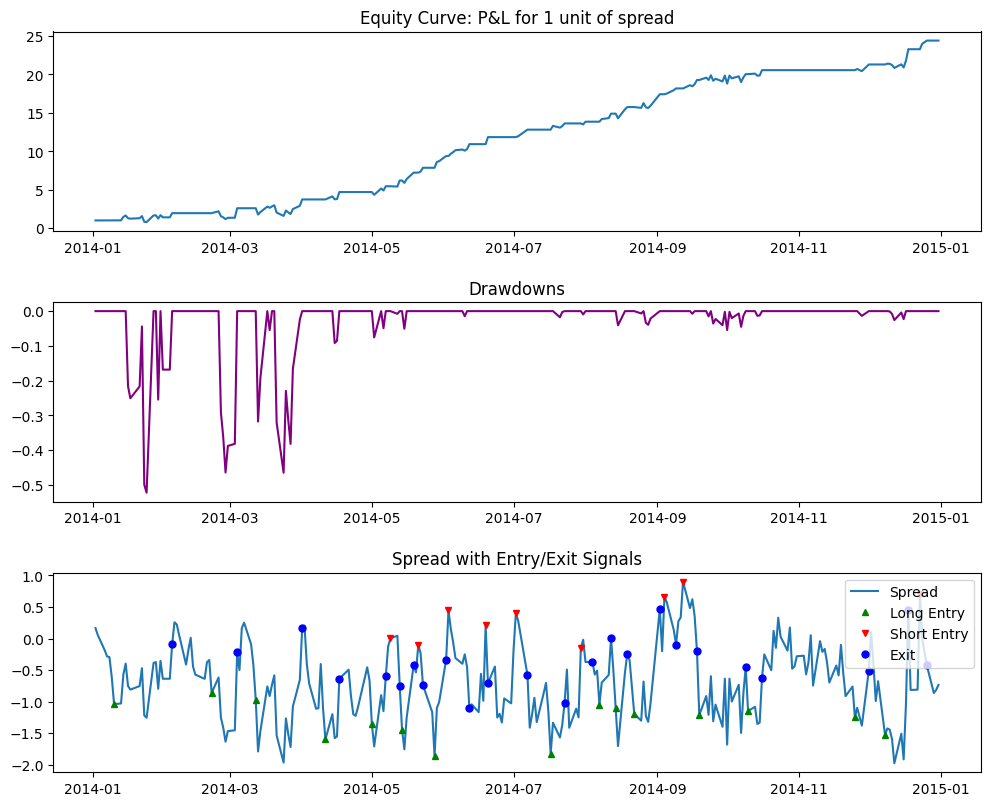

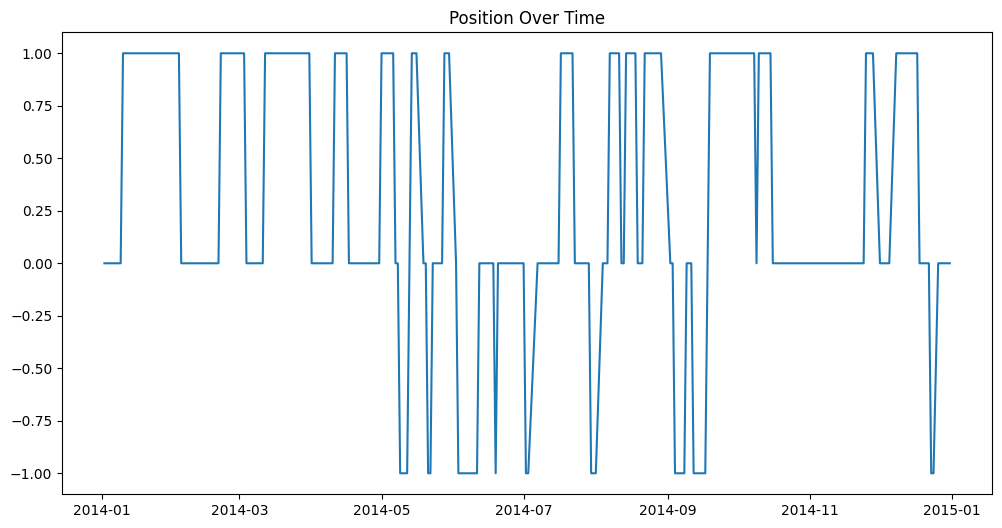

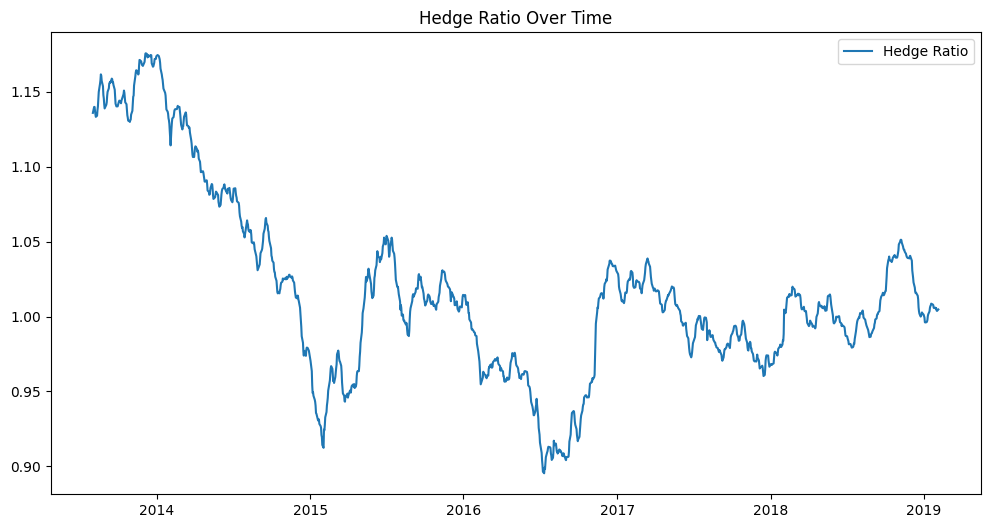

In [121]:
backtester.plot_results(start="2014", end="2014")

<Axes: xlabel='Date'>

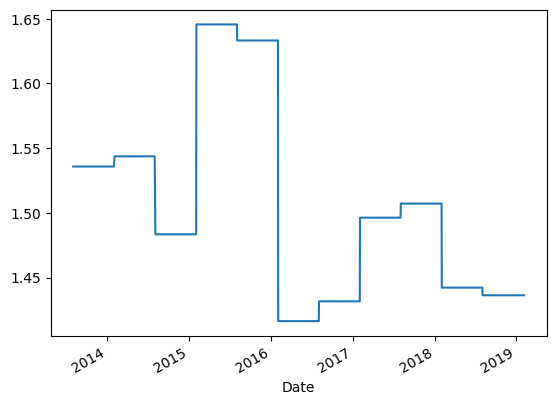

In [ ]:
backtester.half_life_history

In [ ]:
theta1 = strat4.theta_series

In [100]:
strat4.theta_series.tail(20)

Date
2019-01-07 00:00:00+00:00    0.307378
2019-01-08 00:00:00+00:00    0.305555
2019-01-09 00:00:00+00:00    0.305935
2019-01-10 00:00:00+00:00    0.300117
2019-01-11 00:00:00+00:00    0.308361
2019-01-14 00:00:00+00:00    0.310361
2019-01-15 00:00:00+00:00    0.299469
2019-01-16 00:00:00+00:00    0.306262
2019-01-17 00:00:00+00:00    0.310982
2019-01-18 00:00:00+00:00    0.314144
2019-01-22 00:00:00+00:00    0.310198
2019-01-23 00:00:00+00:00    0.310451
2019-01-24 00:00:00+00:00    0.304392
2019-01-25 00:00:00+00:00    0.310846
2019-01-28 00:00:00+00:00    0.311181
2019-01-29 00:00:00+00:00    0.315997
2019-01-30 00:00:00+00:00    0.323659
2019-01-31 00:00:00+00:00    0.318549
2019-02-01 00:00:00+00:00    0.328405
2019-02-04 00:00:00+00:00    0.320447
dtype: float64

In [97]:
theta1.tail(20)

Date
2019-01-07 00:00:00+00:00    0.307378
2019-01-08 00:00:00+00:00    0.305555
2019-01-09 00:00:00+00:00    0.305935
2019-01-10 00:00:00+00:00    0.300117
2019-01-11 00:00:00+00:00    0.308361
2019-01-14 00:00:00+00:00    0.310361
2019-01-15 00:00:00+00:00    0.299469
2019-01-16 00:00:00+00:00    0.306262
2019-01-17 00:00:00+00:00    0.310982
2019-01-18 00:00:00+00:00    0.314144
2019-01-22 00:00:00+00:00    0.310198
2019-01-23 00:00:00+00:00    0.310451
2019-01-24 00:00:00+00:00    0.304392
2019-01-25 00:00:00+00:00    0.310846
2019-01-28 00:00:00+00:00    0.311181
2019-01-29 00:00:00+00:00    0.315997
2019-01-30 00:00:00+00:00    0.323659
2019-01-31 00:00:00+00:00    0.318549
2019-02-01 00:00:00+00:00    0.328405
2019-02-04 00:00:00+00:00    0.320447
dtype: float64

In [785]:
backtester.spreads.loc["2015-01"]

Date
2015-01-02 00:00:00+00:00   -0.701050
2015-01-05 00:00:00+00:00   -1.474338
2015-01-06 00:00:00+00:00   -2.100658
2015-01-07 00:00:00+00:00   -1.059784
2015-01-08 00:00:00+00:00    0.383161
2015-01-09 00:00:00+00:00   -0.309797
2015-01-12 00:00:00+00:00   -0.403925
2015-01-13 00:00:00+00:00   -0.096955
2015-01-14 00:00:00+00:00   -0.375392
2015-01-15 00:00:00+00:00   -0.982306
2015-01-16 00:00:00+00:00    0.134989
2015-01-20 00:00:00+00:00   -0.879900
2015-01-21 00:00:00+00:00    0.283193
2015-01-22 00:00:00+00:00    0.453572
2015-01-23 00:00:00+00:00   -0.494906
2015-01-26 00:00:00+00:00   -0.107659
2015-01-27 00:00:00+00:00   -0.027458
2015-01-28 00:00:00+00:00   -0.951915
2015-01-29 00:00:00+00:00   -0.105255
2015-01-30 00:00:00+00:00   -1.021439
dtype: float64

In [501]:
(backtester.positions.head(30).shift(1) * backtester.spreads.diff().head(30)).sum()

np.float64(2.2267633124971127)

Performance Metrics:


/var/folders/4c/lbq7ysyx5zl93htfdcbr02br0000gn/T/ipykernel_32674/2309814189.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (1 + returns.cumsum()[-1]) ** (1 / total_years) - 1


,Cumulative Return,CAGR,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,Max Drawdown Duration,Win Rate,Average Win,Average Loss,Profit Factor,Average Holding Period
0,93.3986,0.418798,0.156279,0.161628,0.002783,150.477357,1490,0.260379,2.972886,-2.978626,1.038239,0.024122


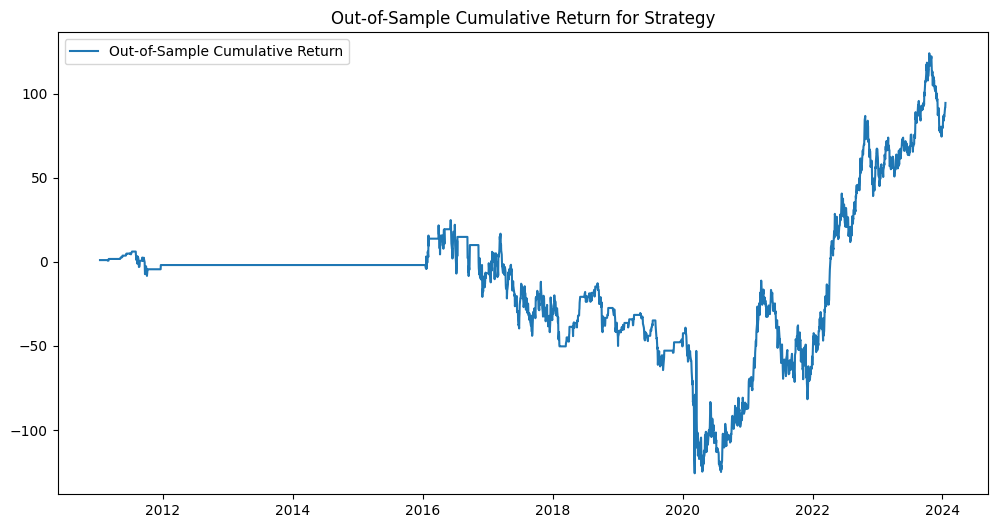

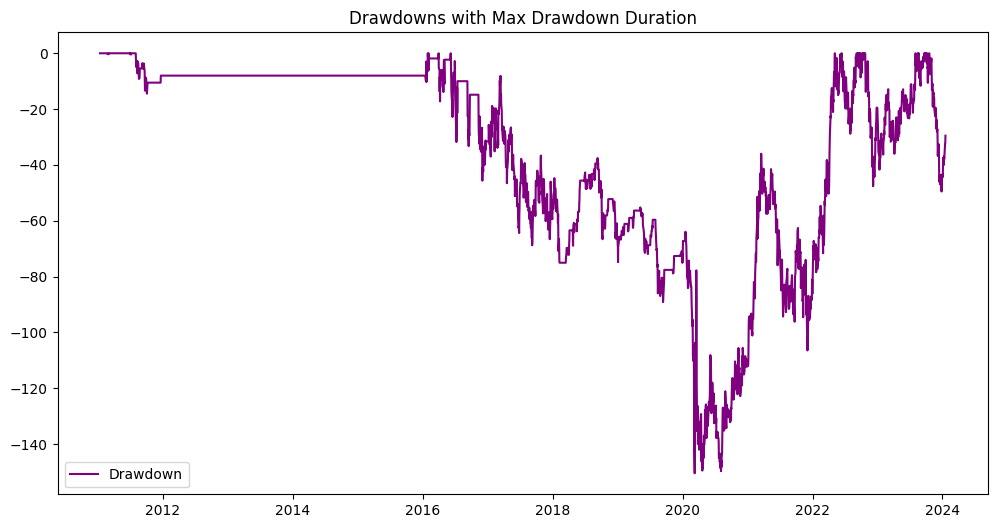

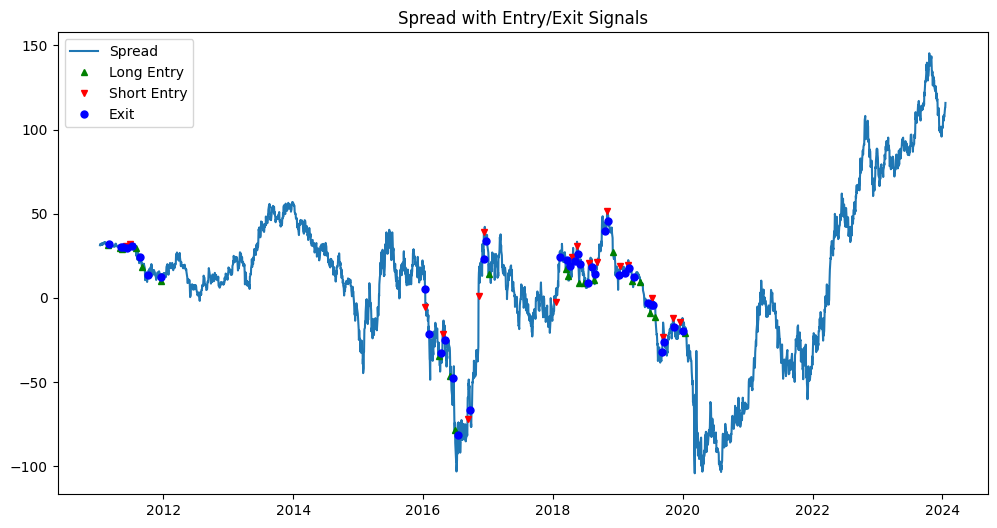

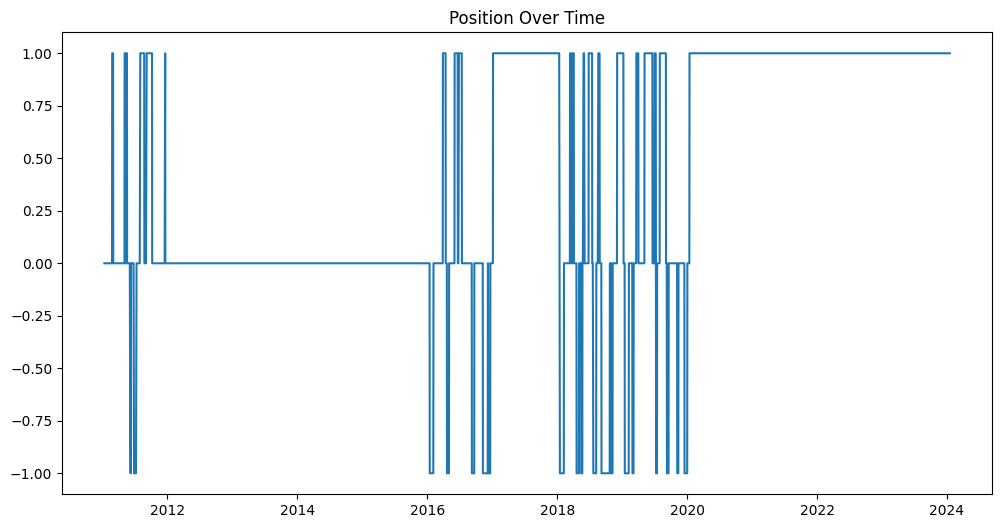

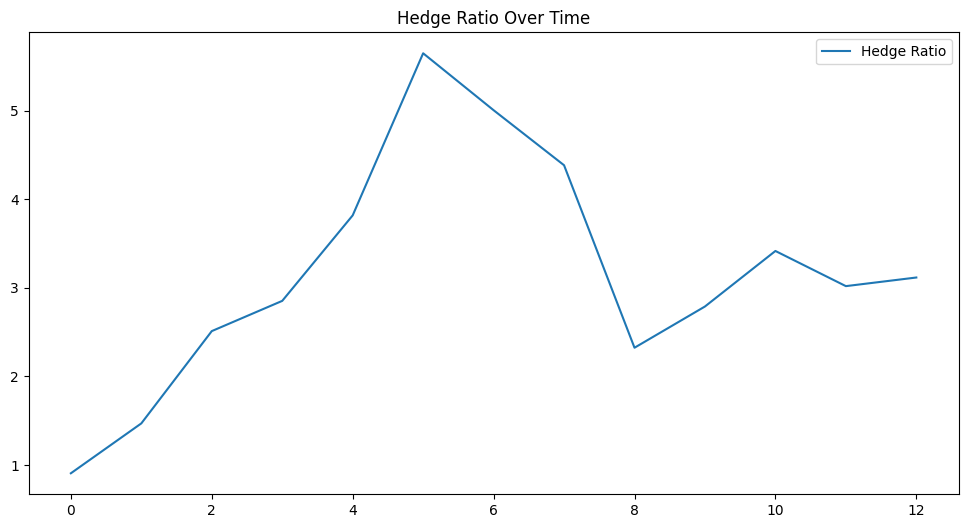

In [ ]:
backtester = Backtester(start_date, end_date, prices, tickers, MeanReversionStrategy(21, 2, 0.5), DynamicHedgeRatioModel())
backtester.run_walk_forward(params, train_window, test_window)
backtester.plot_results()

<Axes: xlabel='date'>

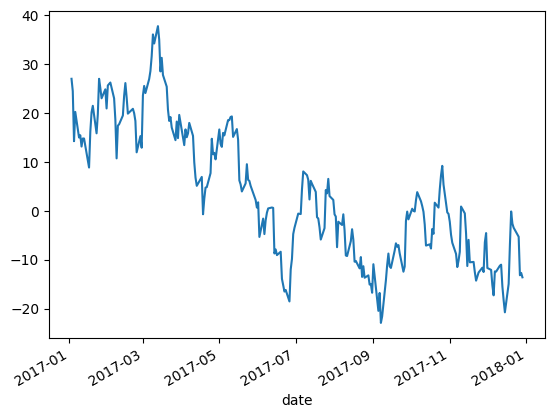

In [438]:
backtester.spreads.loc["2017"].plot()

In [417]:
backtester.spread_returns.loc["2012"].plot()

AttributeError: 'Backtester' object has no attribute 'spread_returns'

<Axes: xlabel='date'>

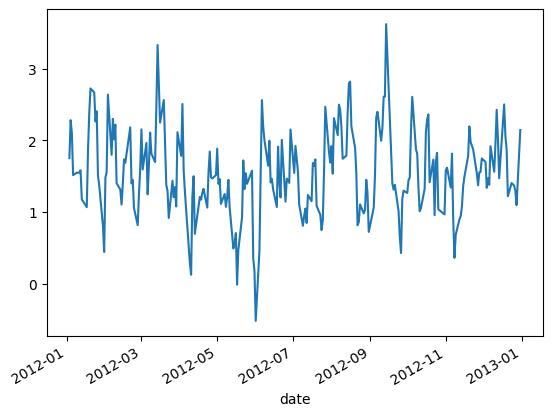

In [400]:
backtester.spreads.loc["2012"].plot()

In [351]:
dyn = DynamicHedgeRatioModel()
hedge_ratio = dyn.compute_hedge_ratio(aaa, ["TLT", "IEI"])

<Axes: xlabel='Date'>

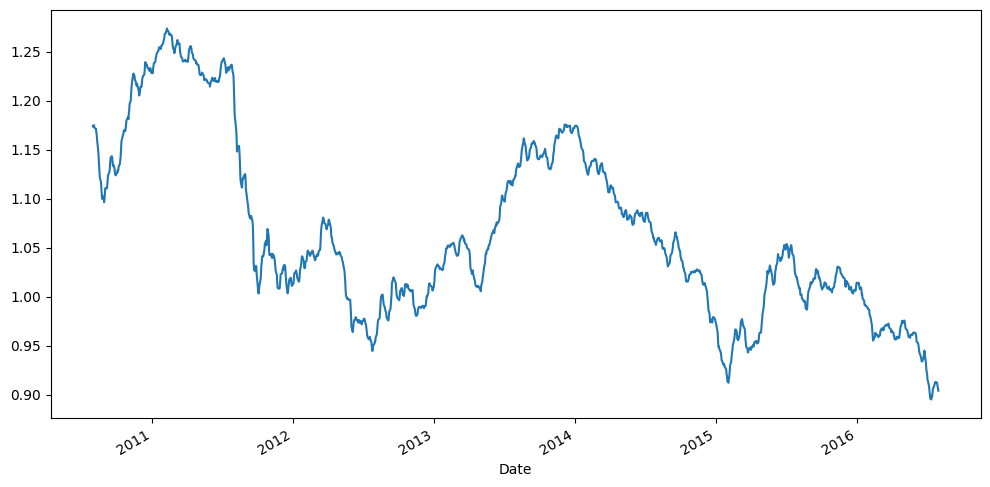

In [353]:
hedge_ratio.plot(figsize=(12, 6))

In [257]:
plt.plot(hedge_ratio[:, 0])

TypeError: tuple indices must be integers or slices, not tuple

In [335]:
aaa = pd.concat([tlt["Close"], iei["Close"]], axis=1)
aaa

Ticker,TLT,IEI
Date,,
2010-08-02 00:00:00+00:00,98.750000,115.940002
2010-08-03 00:00:00+00:00,99.320000,116.440002
2010-08-04 00:00:00+00:00,98.559998,116.059998
2010-08-05 00:00:00+00:00,99.019997,116.370003
2010-08-06 00:00:00+00:00,100.099998,116.730003
...,...,...
2016-07-25 00:00:00+00:00,138.699997,126.550003
2016-07-26 00:00:00+00:00,138.919998,126.580002
2016-07-27 00:00:00+00:00,140.649994,126.889999


<Axes: xlabel='date'>

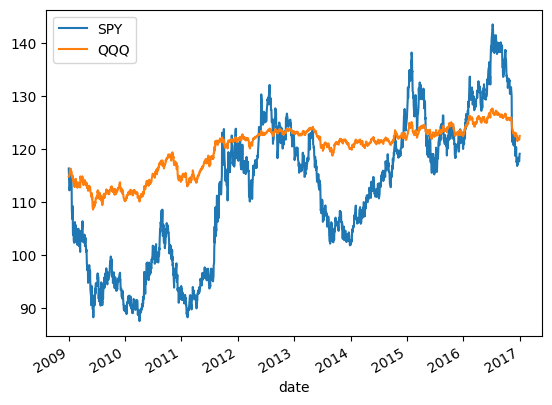

In [336]:
prices.loc["2009": "2016", ["SPY", "QQQ"]].plot()

In [ ]:
def calc_slope_intercept_kalman(etfs, prices):
    delta = 1e-5
    trans_cov = delta / (1 - delta) * np.eye(2)
    obs_mat = np.vstack(
    [prices[etfs[0]], np.ones(prices[etfs[0]].shape)]
    ).T[:, np.newaxis]
    kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=np.zeros(2),
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=1.0,
    transition_covariance=trans_cov
    )
    state_means, state_covs = kf.filter(prices[etfs[1]].values)
    return state_means
coeffs = calc_slope_intercept_kalman(["TLT", "IEI"], aaa)

<Axes: >

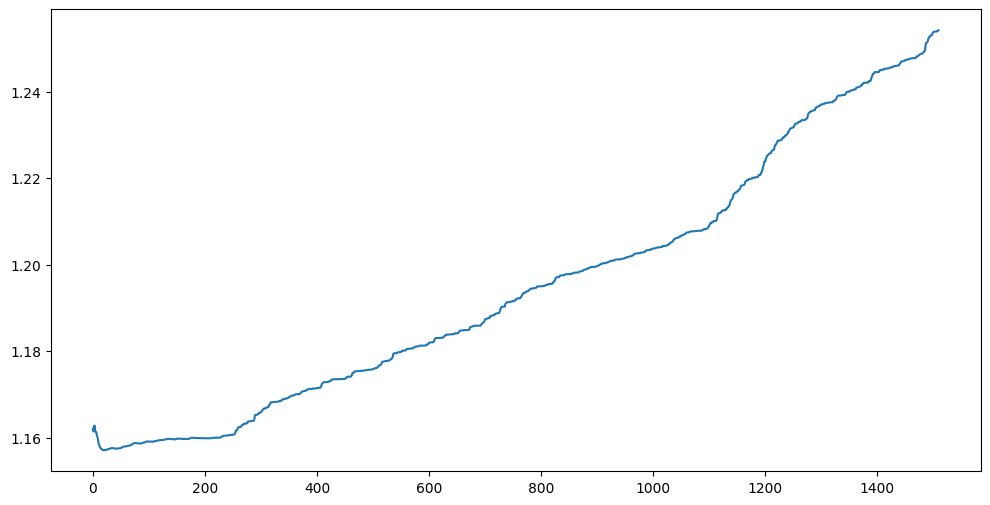

In [338]:
a = pd.Series(coeffs[:, 1])
a.plot(figsize=(12, 6))

<Axes: xlabel='Date'>

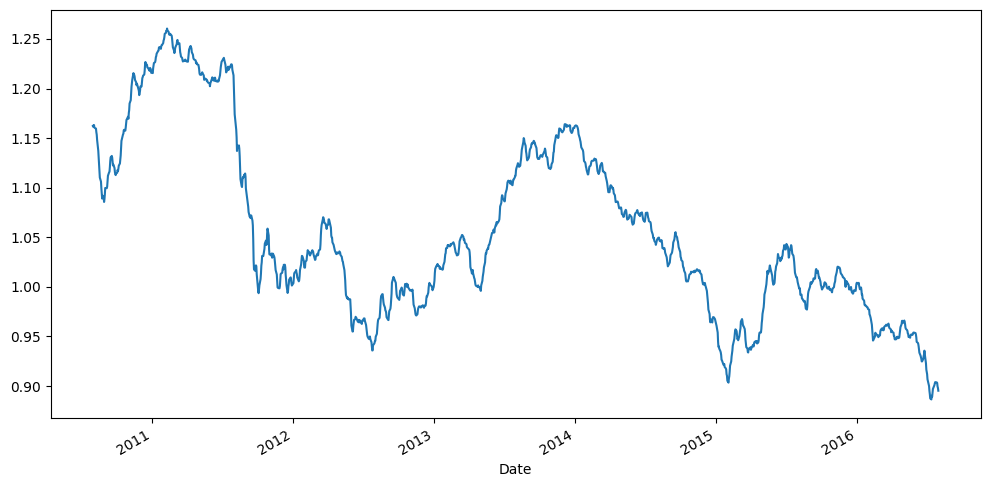

In [339]:
a = pd.Series(coeffs[:, 0], index=aaa.index)
a.plot(figsize=(12, 6))

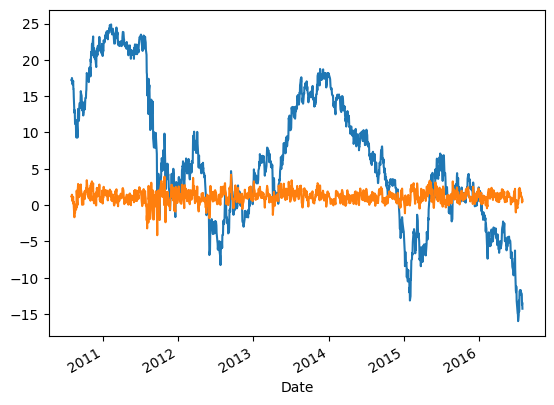

In [ ]:
aaa["unstat_spread"] = aaa["IEI"] - aaa["TLT"]
aaa["stat_spread"] = aaa["IEI"] - (coeffs[:, 0] * aaa["TLT"])
aaa["unstat_spread"].plot()
plt.show()

In [367]:
adfuller(aaa["stat_spread"].loc["2015"])

(np.float64(-8.002728998878634),
 np.float64(2.3106816846113445e-12),
 0,
 251,
 {'1%': np.float64(-3.4566744514553016),
  '5%': np.float64(-2.8731248767783426),
  '10%': np.float64(-2.5729436702592023)},
 np.float64(471.19988193554246))

In [365]:
adfuller(aaa["unstat_spread"])

(np.float64(-0.9690908443048459),
 np.float64(0.7643701482554934),
 7,
 1502,
 {'1%': np.float64(-3.4347111923936393),
  '5%': np.float64(-2.863466189518188),
  '10%': np.float64(-2.5677954794761004)},
 np.float64(3930.5782940172985))

<Axes: xlabel='Date'>

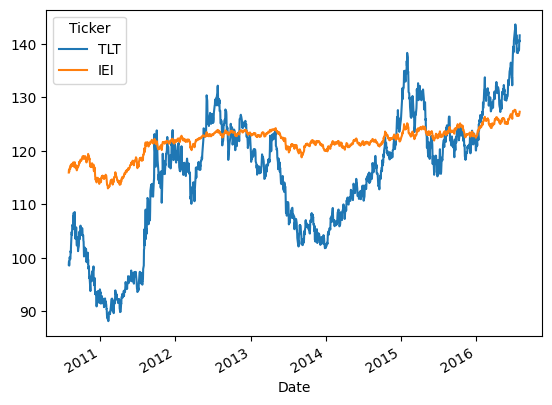

In [454]:
aaa.loc[:, ["TLT", "IEI"]].plot()

In [455]:
aaa.loc[:, ["TLT", "IEI"]]

Ticker,TLT,IEI
Date,,
2010-08-02 00:00:00+00:00,98.750000,115.940002
2010-08-03 00:00:00+00:00,99.320000,116.440002
2010-08-04 00:00:00+00:00,98.559998,116.059998
2010-08-05 00:00:00+00:00,99.019997,116.370003
2010-08-06 00:00:00+00:00,100.099998,116.730003
...,...,...
2016-07-25 00:00:00+00:00,138.699997,126.550003
2016-07-26 00:00:00+00:00,138.919998,126.580002
2016-07-27 00:00:00+00:00,140.649994,126.889999


In [ ]:
class Backtester:
    def __init__(self, start_date, end_date, prices, assets, strategy_class, hedge_ratio_model, half_life=None):
        self.start_date = start_date
        self.end_date = end_date
        self.prices = prices
        self.assets = assets
        self.n = len(assets)
        self.strategy_class = strategy_class
        self.hedge_ratio_model = hedge_ratio_model
        self.half_life = half_life
        self.spreads = []
        self.signal_history = []
        self.positions = None
    
    def compute_hedge_ratio(self, data):
        """Compute hedge ratio based on asset count and dynamic option."""
        if self.n == 2:
            return self.hedge_ratio_model.compute_hedge_ratio(data, self.assets)
        elif self.n > 2:
            return self.compute_static_hedge_ratio_basket(data)
        else:
            raise ValueError("At least two assets are required.")

    def calculate_spread(self, data, hedge_ratio):
        """Calculate spread based on the hedge ratio and asset prices."""
        if self.n == 2:
            return data[self.assets[1]] - hedge_ratio * data[self.assets[0]]
        else:
            return data[self.assets].dot(hedge_ratio)
        
    def calculate_positions(self):
        """Generate positions based on signal history."""
        self.positions = pd.Series(self.signal_history.iloc[0], index=self.signal_history.index)
        trade_duration = 0

        for i in range(1, len(self.signal_history)):
            if self.signal_history['exit'].iloc[i]:       # Exit position
                self.positions.iloc[i] = 0
            elif self.signal_history['long'].iloc[i]:    # Enter long position
                self.positions.iloc[i] = 1
            elif self.signal_history['short'].iloc[i]:  # Enter short position
                self.positions.iloc[i] = -1
            else:
                trade_size += 1
                if self.half_life and trade_duration > self.half_life_history.iloc[i] * self.half_life:
                    self.positions.iloc[i] = 0       # Exit if it takes too much time to mean revert
                else:
                    self.positions.iloc[i] = self.positions.iloc[i - 1]  # Maintain previous position

        return self.positions
    
    def is_valid_pair(self, spread):
        adf_test = adfuller(spread)
        return adf_test[1] <= 0.8
    
    def calculate_returns(self):
        positions = self.calculate_positions()
        returns = self.positions.shift(1) * self.spreads.diff()
        return returns
    
    def run_walk_forward(self, param_grid, train_window, test_window):
        self.spreads = []  
        self.signal_history = []  
        self.hedge_ratio_history = []
        self.half_life_history = []
        previous_spread_end = None  # To adjust spreads between windows

        for start in range(0, len(self.prices) - train_window - test_window + 1, test_window):
            # Split data into train, validation, and test sets
            train_data = self.prices.iloc[start:start + train_window][self.assets]
            test_data = self.prices.iloc[start + train_window:start + train_window + test_window][self.assets]

            # Step 1: Calculate hedge ratio on the training period
            train_hedge_ratio = self.compute_hedge_ratio(train_data)
            train_spread = self.calculate_spread(train_data, train_hedge_ratio)

            # Step 3: Compute spread over train + val + test data
            if isinstance(self.hedge_ratio_model, DynamicHedgeRatioModel):
                test_hedge_ratio = self.compute_hedge_ratio(test_data)
                test_spread = self.calculate_spread(test_data, test_hedge_ratio)
                self.hedge_ratio_history.append(test_hedge_ratio)
            elif isinstance(self.hedge_ratio_model, StaticHedgeRatioModel):
                test_spread = self.calculate_spread(test_data, train_hedge_ratio)
                self.hedge_ratio_history.append(train_hedge_ratio)
            else:
                raise ValueError("Invalid Hedge Ratio Model")

            # Step 4: Adjust the spread for continuity
            if previous_spread_end is not None:
                adjustment = previous_spread_end - test_spread.iloc[0]
                test_spread += adjustment
            previous_spread_end = test_spread.iloc[-1]
            self.spreads.append(test_spread)

            # Trade only if valid pair
            if not self.is_valid_pair(train_spread):
                empty_signals = pd.DataFrame(0, index=test_data.index, columns=['long', 'short', 'exit'])
                self.signal_history.append(empty_signals)
                continue

            if self.half_life:
                half_life = self.compute_half_life(train_spread)
                self.half_life_history.append([half_life]*test_window)

            # Generate signals using the best strategy
            train_test_spread = pd.concat([train_spread, test_spread])
            train_test_signals = self.strategy_class.generate_signals(train_test_spread)
            test_signals = train_test_signals.loc[test_spread.index]
            self.signal_history.append(test_signals)

        # Concatenate results from all windows
        if isinstance(self.hedge_ratio_model, DynamicHedgeRatioModel):
            self.hedge_ratio_history = pd.concat(self.hedge_ratio_history)
        else:
            self.hedge_ratio_history = pd.Series(self.hedge_ratio_history)
        
        #self.hedge_ratio_history = pd.concat(self.hedge_ratio_history)
        self.spreads = pd.concat(self.spreads)
        self.signal_history = pd.concat(self.signal_history)
        self.half_life_history = pd.Series(half_life, index=self.spreads)
    
    def compute_half_life(self, spread):
        theta, _, _ = estimate_ou_parameters_mle(spread)
        return np.log(2) / theta